# 04. DBSCAN Clustering — Complete

This notebook develops **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** from intuition to implementation and practical evaluation.

We will use the same pedagogical style as the previous clustering notebook:

- concept → mathematics → algorithm,
- a step-by-step synthetic example,
- a NumPy implementation from scratch,
- Scikit-learn implementation,
- visualization and evaluation,
- practical parameter selection,
- failure cases and computational considerations,
- applications in biology, medical AI, and general data science.


# 1. Problem & Motivation

Many clustering methods assume that clusters are approximately compact, convex, or centered around representative points.

That assumption can be problematic when:

- clusters have irregular shapes,
- the number of clusters is unknown,
- the dataset contains outliers,
- some observations do not naturally belong to any cluster.

DBSCAN approaches clustering from a different perspective:

> **A cluster is a region of sufficiently high point density separated from regions of lower density.**

This makes DBSCAN especially useful for discovering non-convex groups and explicitly identifying noise.


# 2. What Is Density-Based Clustering?

Density-based clustering groups observations according to the local concentration of points.

Instead of asking:

> “Which centroid is this observation closest to?”

we ask:

> “Is this observation located inside a sufficiently dense neighborhood?”

DBSCAN is based mainly on two parameters:

- `eps` (ε): neighborhood radius.
- `min_samples`: minimum number of observations required for a point to be considered dense.

A useful mental model is a circle of radius ε moving around the dataset.

If enough observations fall inside that circle, the region is considered dense.


# 3. DBSCAN Intuition

Imagine observations scattered across a two-dimensional space.

A dense cloud contains many nearby points. Sparse regions contain only a few.

DBSCAN expands a cluster when it encounters **core points** and can attach nearby **border points** to that cluster.

Points that are not sufficiently connected to any dense region become **noise**.

This gives DBSCAN three important behaviors:

1. Discover clusters without specifying the number of clusters in advance.
2. Find non-convex cluster shapes.
3. Label some observations as noise.


# 4. Neighborhood and ε

For a point $x_i$, define its ε-neighborhood as:

$$
N_\varepsilon(x_i)
=
\{x_j \mid d(x_i,x_j) \leq \varepsilon\}
$$

where:

- $d(\cdot,\cdot)$ is a distance function,
- ε controls the radius of the neighborhood.

A small ε creates small neighborhoods and may produce many noise points.

A large ε creates large neighborhoods and may merge distinct groups.

Therefore, ε is not just a technical parameter: it defines what “nearby” means for the problem.


# 5. `min_samples`

`min_samples` controls how many observations must be present in a point's ε-neighborhood for the point to be considered a **core point**.

For example, if:

- `eps = 0.5`
- `min_samples = 5`

then a point must have at least 5 observations in its ε-neighborhood under the convention used by Scikit-learn.

Larger values make the density requirement stricter.

The best value depends on:

- sample size,
- dimensionality,
- noise level,
- scientific meaning of local density.


# 6. Core, Border, and Noise Points

DBSCAN classifies observations conceptually into three categories.

### Core point

A point whose ε-neighborhood contains at least `min_samples` observations.

### Border point

A point that is not itself dense enough to be core, but lies within the ε-neighborhood of a core point.

### Noise point

A point that is neither a core point nor density-reachable from a core point.

This distinction is central to understanding DBSCAN.

The cluster therefore grows from **dense cores**, while border observations can be attached to those cores.


# 7. Mathematical Definition

Let $N_\varepsilon(p)$ denote the $\varepsilon$-neighborhood of point $p$.

A point $p$ is a **core point** when:

$$
|N_\varepsilon(p)| \geq \text{min\_samples}
$$

A point $q$ is directly density-reachable from $p$ when:

1. $q \in N_\varepsilon(p)$
2. $p$ is a core point.

Density reachability can then propagate through a chain of core points.

This allows DBSCAN to follow curved or otherwise non-convex structures without requiring a centroid.

# 8. DBSCAN Algorithm

A simplified version of the algorithm is:

1. Select an unvisited point.
2. Find all points in its ε-neighborhood.
3. If the neighborhood is too small, temporarily mark the point as noise.
4. If the neighborhood is dense enough, create a new cluster.
5. Expand the cluster through neighboring core points.
6. Continue until no more density-connected points can be added.
7. Repeat until every observation has been processed.

The important idea is that a cluster is **grown locally from density**, rather than assigned globally to a centroid.


# 9. Step-by-Step Example

We begin with a small synthetic dataset containing:

- two dense groups,
- a few isolated observations.

The goal is to see how DBSCAN can identify the two groups while leaving isolated observations as noise.


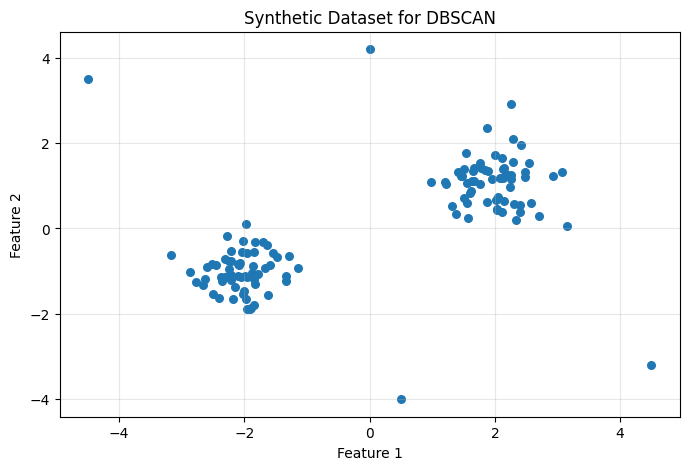

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42

# Small educational dataset.
X_small, y_small_true = make_blobs(
    n_samples=120,
    centers=[(-2, -1), (2, 1)],
    cluster_std=[0.45, 0.50],
    random_state=RANDOM_STATE
)

# Add a few isolated points to make the noise behavior visible.
noise_points = np.array([
    [-4.5, 3.5],
    [4.5, -3.2],
    [0.0, 4.2],
    [0.5, -4.0]
])

X_small = np.vstack([X_small, noise_points])

plt.figure(figsize=(8, 5))
plt.scatter(X_small[:, 0], X_small[:, 1], s=30)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Dataset for DBSCAN")
plt.grid(alpha=0.3)
plt.show()


# 10. From-Scratch NumPy Implementation

For learning purposes, we can implement the essential DBSCAN logic ourselves.

The implementation below intentionally favors clarity over production-level optimization.

The main helper is `region_query`, which returns the indices of points within ε of a given observation.

Then `expand_cluster` grows a cluster by repeatedly examining newly discovered neighbors.


In [2]:
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))


def region_query(X, point_index, eps):
    """Return indices of all points within eps of X[point_index]."""
    distances = np.sqrt(np.sum((X - X[point_index]) ** 2, axis=1))
    return np.where(distances <= eps)[0]


def dbscan_from_scratch(X, eps=0.5, min_samples=5):
    """Educational DBSCAN implementation using NumPy."""
    n_samples = len(X)

    UNVISITED = -2
    NOISE = -1

    labels = np.full(n_samples, UNVISITED, dtype=int)
    cluster_id = 0

    for point_index in range(n_samples):
        if labels[point_index] != UNVISITED:
            continue

        neighbors = region_query(X, point_index, eps)

        if len(neighbors) < min_samples:
            labels[point_index] = NOISE
            continue

        labels[point_index] = cluster_id

        # Use a list so newly discovered neighbors can be appended.
        seeds = list(neighbors)

        i = 0
        while i < len(seeds):
            neighbor_index = seeds[i]

            if labels[neighbor_index] == NOISE:
                # A previously marked noise point can become a border point.
                labels[neighbor_index] = cluster_id

            if labels[neighbor_index] != UNVISITED:
                i += 1
                continue

            labels[neighbor_index] = cluster_id
            neighbor_neighbors = region_query(X, neighbor_index, eps)

            if len(neighbor_neighbors) >= min_samples:
                for candidate in neighbor_neighbors:
                    if candidate not in seeds:
                        seeds.append(candidate)

            i += 1

        cluster_id += 1

    return labels


scratch_labels = dbscan_from_scratch(
    X_small,
    eps=0.55,
    min_samples=5
)

np.unique(scratch_labels, return_counts=True)


(array([-1,  0,  1]), array([ 5, 60, 59]))

# 11. Visualization of Core / Border / Noise

The DBSCAN result can be visualized using three categories:

- **Core points**: dense enough to expand clusters.
- **Border points**: attached to a dense region but not dense themselves.
- **Noise points**: not assigned to any cluster.

Scikit-learn exposes the core sample indices, which makes this distinction easy to inspect.


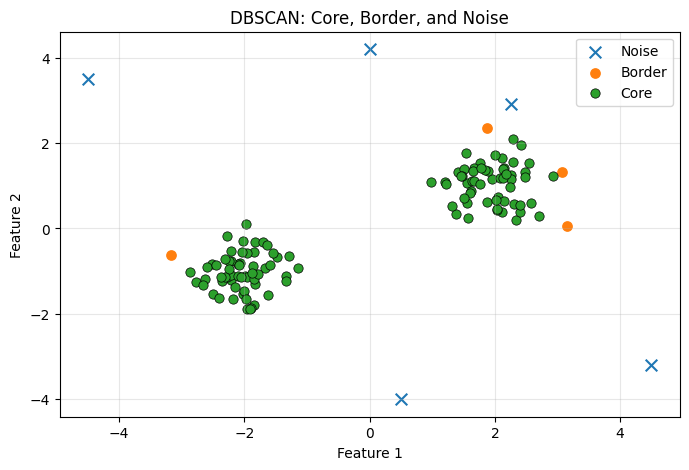

In [3]:
model_small = DBSCAN(
    eps=0.55,
    min_samples=5
)

labels_small = model_small.fit_predict(X_small)

core_mask = np.zeros(len(X_small), dtype=bool)
core_mask[model_small.core_sample_indices_] = True

noise_mask = labels_small == -1
border_mask = (~core_mask) & (~noise_mask)

plt.figure(figsize=(8, 5))

plt.scatter(
    X_small[noise_mask, 0],
    X_small[noise_mask, 1],
    marker="x",
    s=70,
    label="Noise"
)

plt.scatter(
    X_small[border_mask, 0],
    X_small[border_mask, 1],
    s=45,
    label="Border"
)

plt.scatter(
    X_small[core_mask, 0],
    X_small[core_mask, 1],
    s=45,
    edgecolor="black",
    linewidth=0.5,
    label="Core"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN: Core, Border, and Noise")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 12. Scikit-learn Implementation

Scikit-learn provides a practical implementation through `DBSCAN`.

Important parameters include:

- `eps`: neighborhood radius.
- `min_samples`: density threshold.
- `metric`: distance metric.
- `algorithm`: neighborhood-search strategy.
- `n_jobs`: parallelization option where supported.

DBSCAN returns cluster labels through `fit_predict`.

The label `-1` conventionally represents noise.


In [4]:
dbscan_model = DBSCAN(
    eps=0.55,
    min_samples=5,
    metric="euclidean"
)

dbscan_labels = dbscan_model.fit_predict(X_small)

print("Unique labels:", np.unique(dbscan_labels))
print("Number of clusters:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Number of noise points:", np.sum(dbscan_labels == -1))


Unique labels: [-1  0  1]
Number of clusters: 2
Number of noise points: 5


# 13. Choosing `eps`

Choosing ε is often the most important practical decision in DBSCAN.

If ε is too small:

- many points become noise,
- dense groups may fragment,
- cluster expansion may stop too early.

If ε is too large:

- distinct groups can merge,
- sparse regions may be absorbed,
- the algorithm may classify too many observations as part of clusters.

A useful strategy is to inspect a **k-distance plot** and look for an approximate change in slope, often called an elbow or knee.


# 14. k-Distance Plot

For a chosen value of `min_samples`, compute the distance from every observation to its k-th nearest neighbor.

After sorting these distances, a sharp change in slope can provide a useful starting point for ε.

This is a heuristic, not a universal automatic rule.

The final ε should also be checked using:

- domain knowledge,
- cluster visualization,
- noise proportion,
- stability across nearby parameter values.


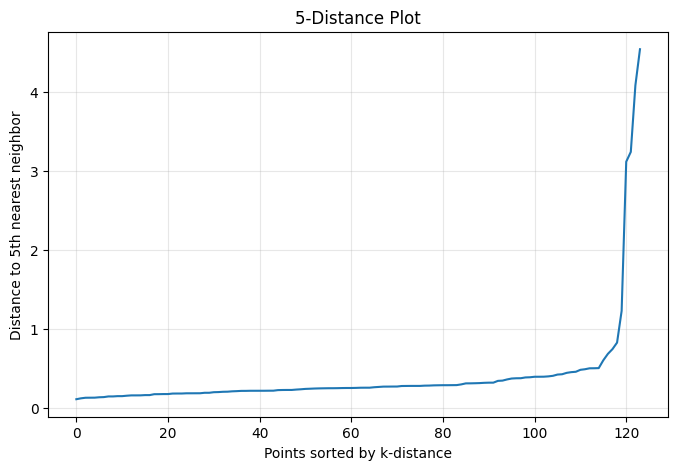

In [5]:
def plot_k_distance(X, k=5):
    # k-th nearest neighbor distance.
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors.fit(X)

    distances, _ = neighbors.kneighbors(X)

    k_distances = np.sort(distances[:, -1])

    plt.figure(figsize=(8, 5))
    plt.plot(k_distances)
    plt.xlabel("Points sorted by k-distance")
    plt.ylabel(f"Distance to {k}th nearest neighbor")
    plt.title(f"{k}-Distance Plot")
    plt.grid(alpha=0.3)
    plt.show()

    return k_distances


k_distances = plot_k_distance(X_small, k=5)


# 15. Choosing `min_samples`

There is no single universally correct value for `min_samples`.

Increasing it makes DBSCAN require stronger local density.

Smaller values:

- make clusters easier to form,
- but can make the method more sensitive to small accidental concentrations.

Larger values:

- make density requirements stricter,
- can suppress small clusters,
- can increase the number of noise points.

A common practical starting point is to relate `min_samples` to dimensionality and then test several nearby values rather than treating one formula as a law.


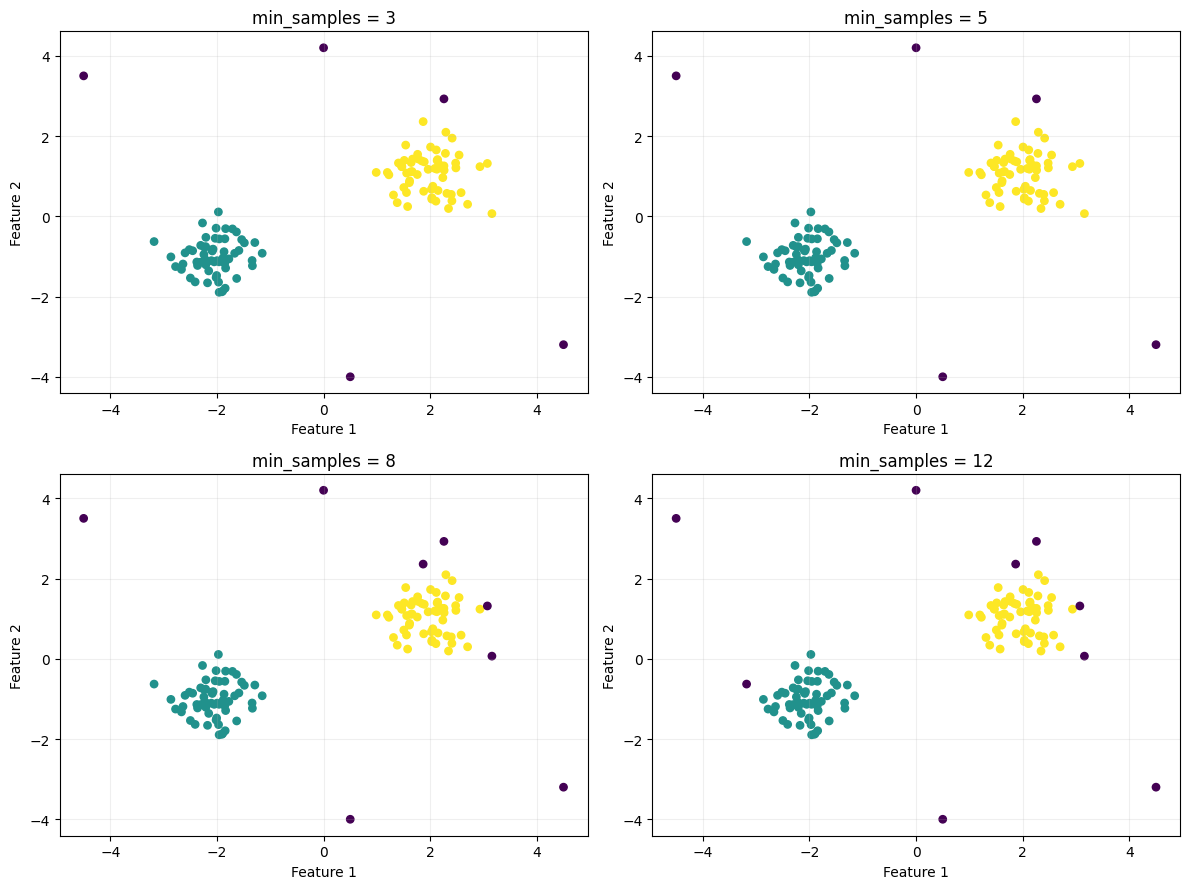

In [6]:
# Compare several min_samples values while keeping eps fixed.
min_samples_values = [3, 5, 8, 12]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, min_samples in zip(axes.ravel(), min_samples_values):
    labels = DBSCAN(
        eps=0.55,
        min_samples=min_samples
    ).fit_predict(X_small)

    ax.scatter(
        X_small[:, 0],
        X_small[:, 1],
        c=labels,
        s=28
    )
    ax.set_title(f"min_samples = {min_samples}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# 16. Feature Scaling

DBSCAN is distance-based, so feature scale directly affects neighborhood membership.

Suppose:

- Feature A ranges from 0 to 1.
- Feature B ranges from 0 to 100,000.

With Euclidean distance, Feature B can dominate the neighborhood calculation.

Standardization is often appropriate when features are measured on substantially different scales:

$$
z = \frac{x - \mu}{\sigma}
$$

However, scaling should be a modeling decision. If the original units have a meaningful distance interpretation, transformation should be justified rather than applied automatically.


In [7]:
# Create an intentionally differently scaled version.
X_scaled = StandardScaler().fit_transform(X_small)

scale_comparison = pd.DataFrame({
    "original_mean": X_small.mean(axis=0),
    "original_std": X_small.std(axis=0),
    "scaled_mean": X_scaled.mean(axis=0),
    "scaled_std": X_scaled.std(axis=0)
})

scale_comparison


,original_mean,original_std,scaled_mean,scaled_std
0,-0.032707,2.108435,-8.550508e-17,1.0
1,0.042277,1.327708,7.162729e-18,1.0


# 17. Silhouette Score

The Silhouette Score evaluates how well observations fit their assigned clusters.

For observation $i$:

- $a(i)$ is the average distance to observations in its own cluster.
- $b(i)$ is the smallest average distance to observations in another cluster.

The silhouette coefficient is:

$$
s(i)
=
\frac{b(i)-a(i)}
{\max(a(i),b(i))}
$$

The average score is often higher when clusters are compact and well separated.

**Important DBSCAN caveat:** noise points (`-1`) should generally be excluded before computing a conventional silhouette score, and silhouette alone can be misleading for irregular or density-based cluster structures.


In [8]:
def dbscan_silhouette(X, labels):
    """Silhouette score using only non-noise observations."""
    mask = labels != -1
    X_clustered = X[mask]
    labels_clustered = labels[mask]

    if len(np.unique(labels_clustered)) < 2:
        return np.nan

    return silhouette_score(X_clustered, labels_clustered)


silhouette_dbscan = dbscan_silhouette(X_small, dbscan_labels)
print(f"Silhouette Score (excluding noise): {silhouette_dbscan:.4f}")


Silhouette Score (excluding noise): 0.8243


# 18. Adjusted Rand Index

When ground-truth labels are available, the **Adjusted Rand Index (ARI)** can compare the discovered partition with the known partition.

ARI adjusts for agreement that could occur by chance.

Interpretation is roughly:

- 1: strong agreement,
- 0: agreement comparable to random labeling under the adjustment,
- negative values: agreement worse than the expected chance baseline.

ARI is especially useful for synthetic experiments where the true generating clusters are known.

For real unsupervised datasets, true labels may not exist, so ARI cannot always be used.


In [9]:
# For this synthetic example, use the known blob labels for the original observations.
# The last few manually added noise points have no corresponding ground-truth class,
# so we evaluate ARI only on the original generated observations.

ari = adjusted_rand_score(
    y_small_true,
    dbscan_labels[:len(y_small_true)]
)

print(f"Adjusted Rand Index on generated observations: {ari:.4f}")


Adjusted Rand Index on generated observations: 0.9835


# 19. Two-Moons / Non-Convex Clusters

One of DBSCAN's strongest conceptual advantages is its ability to discover non-convex shapes.

Two interlocking half-moons are a classic example.

A centroid-based method such as K-Means can struggle because each moon is not naturally represented by a compact spherical region.

DBSCAN can follow the dense geometry of each moon when ε and `min_samples` are appropriate.


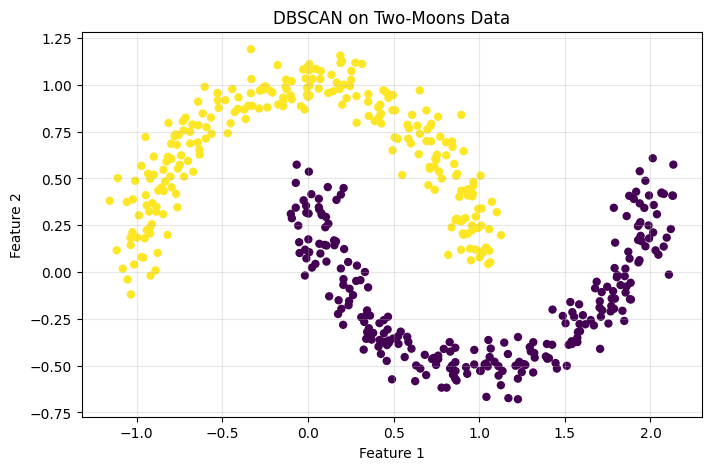

ARI: 1.0


In [10]:
# Generate two non-convex moon-shaped clusters.
X_moons, y_moons_true = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=RANDOM_STATE
)

moon_model = DBSCAN(
    eps=0.20,
    min_samples=5
)

moon_labels = moon_model.fit_predict(X_moons)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_moons[:, 0],
    X_moons[:, 1],
    c=moon_labels,
    s=25
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN on Two-Moons Data")
plt.grid(alpha=0.3)
plt.show()

print("ARI:", adjusted_rand_score(y_moons_true, moon_labels))


# 20. K-Means vs Hierarchical vs DBSCAN

| Property | K-Means | Hierarchical | DBSCAN |
|---|---|---|---|
| Choose number of clusters directly | Yes | Often after hierarchy | No |
| Produces hierarchy | No | Yes | No |
| Handles non-convex clusters | Limited | Depends on linkage | Often strong |
| Explicit noise label | No | No | Yes |
| Main control parameter | `n_clusters` | linkage / cut | `eps`, `min_samples` |
| Sensitive to feature scale | Yes | Yes | Yes |
| Typical representation | Centroids | Dendrogram | Density-connected regions |
| Large datasets | Often scalable | Can be expensive | Neighborhood search can be expensive |
| Unequal density | Often problematic | Depends on linkage | Can be problematic |
| Interpretability | Centroid-based | Hierarchical | Density-based |

No algorithm is universally best.

The geometry and scientific meaning of the dataset should determine the method.


# 21. Outlier Detection

DBSCAN naturally identifies observations that are not density-connected to any cluster.

These observations receive label `-1`.

This makes DBSCAN useful for exploratory outlier detection.

However, **DBSCAN noise is not automatically equivalent to a scientifically confirmed anomaly**.

A point may be labeled noise because:

- the density threshold is too strict,
- the feature representation is poor,
- the distance metric is inappropriate,
- the observation belongs to a rare but legitimate subgroup.

Outlier interpretation therefore requires domain validation.


In [11]:
# Summarize the DBSCAN result as a compact table.
unique_labels, counts = np.unique(dbscan_labels, return_counts=True)

cluster_summary = pd.DataFrame({
    "label": unique_labels,
    "count": counts
})

cluster_summary["type"] = np.where(
    cluster_summary["label"] == -1,
    "noise",
    "cluster"
)

cluster_summary


,label,count,type
0,-1,5,noise
1,0,60,cluster
2,1,59,cluster


# 22. Failure Cases

DBSCAN has important limitations.

### 1. ε is poorly chosen

Too small fragments clusters and labels many points as noise. Too large merges groups.

### 2. Clusters have very different densities

A single global ε may be appropriate for one cluster but inappropriate for another.

### 3. High-dimensional distance becomes less informative

Neighborhoods can become difficult to distinguish as dimensionality increases.

### 4. Feature scale is inappropriate

Distance calculations can be dominated by a subset of variables.

### 5. Sparse legitimate groups

Small but scientifically meaningful groups may be labeled noise.

### 6. Distance metric is inappropriate

DBSCAN inherits the assumptions of the chosen metric.

### 7. Boundary sensitivity

Small changes in ε can sometimes produce large changes in the final partition.


# 23. High-Dimensional Data

DBSCAN is fundamentally a neighborhood-based algorithm.

In high-dimensional spaces, several issues can appear:

- distances may become less discriminative,
- neighborhoods can become unexpectedly sparse,
- ε becomes harder to interpret,
- computational cost can increase,
- parameter sensitivity can become stronger.

Possible strategies include:

- scientifically justified feature selection,
- dimensionality reduction,
- domain-specific distance metrics,
- careful scaling,
- comparing several parameter settings.

Dimensionality reduction should not be treated as a guaranteed cure; it can also distort distances and density.


In [12]:
# A simple high-dimensional synthetic example.
rng = np.random.default_rng(RANDOM_STATE)

X_high = rng.normal(
    size=(300, 20)
)

# Standardize to make the feature scales comparable.
X_high_scaled = StandardScaler().fit_transform(X_high)

high_model = DBSCAN(
    eps=2.5,
    min_samples=10
)

high_labels = high_model.fit_predict(X_high_scaled)

print("Dimensions:", X_high_scaled.shape[1])
print("Clusters found:", len(set(high_labels)) - (1 if -1 in high_labels else 0))
print("Noise fraction:", np.mean(high_labels == -1))


Dimensions: 20
Clusters found: 0
Noise fraction: 1.0


# 24. Computational Considerations

DBSCAN repeatedly needs neighborhood information.

The practical cost therefore depends strongly on:

- number of observations,
- number of features,
- distance metric,
- neighborhood-search implementation,
- data structure used by the implementation.

Scikit-learn can use different neighborhood-search strategies through its `algorithm` parameter.

For large datasets, consider:

- appropriate indexing / nearest-neighbor methods,
- reducing unnecessary dimensions,
- sparse representations when justified,
- alternative clustering methods when density search becomes impractical.

The asymptotic behavior also depends on the metric and data geometry, so one should avoid assuming a single runtime formula applies to every DBSCAN workload.


# 25. Practical Workflow

A practical DBSCAN workflow can be organized as:

$$
\text{Raw Data}
\rightarrow
\text{Quality Checks}
\rightarrow
\text{Feature Design}
\rightarrow
\text{Scaling}
\rightarrow
\text{Choose Metric}
\rightarrow
\text{k-Distance Analysis}
\rightarrow
\text{DBSCAN}
\rightarrow
\text{Inspect Noise}
\rightarrow
\text{Evaluate}
\rightarrow
\text{Domain Interpretation}
$$

A useful checklist is:

1. Inspect missing values and measurement quality.
2. Decide which observations and features should be clustered.
3. Decide whether scaling is appropriate.
4. Choose a meaningful distance metric.
5. Explore candidate `eps` values.
6. Explore candidate `min_samples` values.
7. Inspect the number and geometry of clusters.
8. Inspect the fraction and identity of noise points.
9. Use internal metrics carefully.
10. Validate the result using domain knowledge.


In [13]:
# A small parameter sweep for practical exploration.
eps_values = [0.35, 0.45, 0.55, 0.65, 0.75]
min_samples = 5

workflow_results = []

for eps in eps_values:
    labels = DBSCAN(
        eps=eps,
        min_samples=min_samples
    ).fit_predict(X_small)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_fraction = np.mean(labels == -1)
    silhouette = dbscan_silhouette(X_small, labels)

    workflow_results.append({
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "noise_fraction": noise_fraction,
        "silhouette_excluding_noise": silhouette
    })

workflow_results = pd.DataFrame(workflow_results)
workflow_results


,eps,min_samples,n_clusters,noise_fraction,silhouette_excluding_noise
0,0.35,5,2,0.137097,0.841753
1,0.45,5,2,0.080645,0.831728
2,0.55,5,2,0.040323,0.824330
3,0.65,5,2,0.040323,0.824330
4,0.75,5,2,0.032258,0.821371


# 26. Applications in Biology / Medical AI / General Data Science

DBSCAN can be useful when the scientific question is naturally about **local similarity or density**.

### Biology

Possible applications include:

- exploratory clustering of cells or samples,
- identifying dense phenotypic groups,
- finding spatially localized biological observations,
- detecting unusual samples for follow-up.

### Medical AI

Potential exploratory uses include:

- grouping patient representations,
- detecting unusual feature profiles,
- exploring embedding spaces,
- identifying dense subpopulations.

These applications require careful validation. A DBSCAN noise label should not automatically be interpreted as disease, fraud, pathology, or clinical abnormality.

### General Data Science

Examples include:

- spatial event analysis,
- geographic point clustering,
- customer or behavior embeddings,
- anomaly-oriented exploration,
- discovering irregularly shaped groups.


# 27. Key Takeaways

The most important ideas are:

- **DBSCAN is density-based.**
- `eps` defines the neighborhood radius.
- `min_samples` controls the density threshold.
- **Core points** can expand clusters.
- **Border points** can belong to a cluster without being dense enough to expand it.
- **Noise points** are labeled `-1`.
- DBSCAN can discover **non-convex clusters**.
- It does **not** require the number of clusters to be specified in advance.
- Feature scaling and the distance metric can strongly affect the result.
- `eps` and `min_samples` should be selected using diagnostics and domain knowledge.
- Silhouette and ARI can be useful, but each has limitations.
- A noise label is an algorithmic result, not automatically a scientific anomaly.
- DBSCAN can struggle when clusters have substantially different densities or when dimensionality is high.


# 28. References

1. Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). **A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise.** Proceedings of KDD.
2. Schubert, E., Sander, J., Ester, M., Kriegel, H. P., & Xu, X. (2017). **DBSCAN Revisited, Revisited: Why and How You Should (Still) Use DBSCAN.** ACM Transactions on Database Systems.
3. Pedregosa, F. et al. (2011). **Scikit-learn: Machine Learning in Python.** Journal of Machine Learning Research.
4. Scikit-learn documentation: **DBSCAN** and clustering evaluation metrics.
5. Hastie, T., Tibshirani, R., & Friedman, J. **The Elements of Statistical Learning.** Springer.
6. Aggarwal, C. C. (2015). **Data Mining: The Textbook.** Springer.
